In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
!pip install darts
!pip install optuna
from darts.models import ARIMA
import optuna
from darts import TimeSeries
from darts.metrics import mape, mae, mse, mql
from darts.models import ExponentialSmoothing, Prophet, XGBModel
from darts.utils.utils import ModelMode, SeasonalityMode
from darts.utils.likelihood_models.torch import QuantileRegression

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.2/393.2 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.2 MB/s eta 0:00:00


In [ ]:
data = pd.read_csv('electricity_consumption_and_production.csv')
print(f"Dataset shape: ", data.shape)
print(data.head())

Dataset shape:  (54161, 10)
              DateTime  Consumption  Production  Nuclear  Wind  Hydroelectric  \
0  2019-01-01 00:00:00         6352        6527     1395    79           1383   
1  2019-01-01 01:00:00         6116        5701     1393    96           1112   
2  2019-01-01 02:00:00         5873        5676     1393   142           1030   
3  2019-01-01 03:00:00         5682        5603     1397   191            972   
4  2019-01-01 04:00:00         5557        5454     1393   159            960   

   Oil and Gas  Coal  Solar  Biomass  
0         1896  1744      0       30  
1         1429  1641      0       30  
2         1465  1616      0       30  
3         1455  1558      0       30  
4         1454  1458      0       30  


In [ ]:
def data_preprocessing(data):
  data['DateTime'] = pd.to_datetime(data['DateTime'])
  data.set_index('DateTime', inplace = True)
  data = data.interpolate()
  daily_data = data.resample('D').mean()
  return daily_data
data = data_preprocessing(data)
pd_series = data['Consumption']
pd_series = data['Consumption'].interpolate()

In [ ]:
pd_series = data['Consumption'].interpolate()

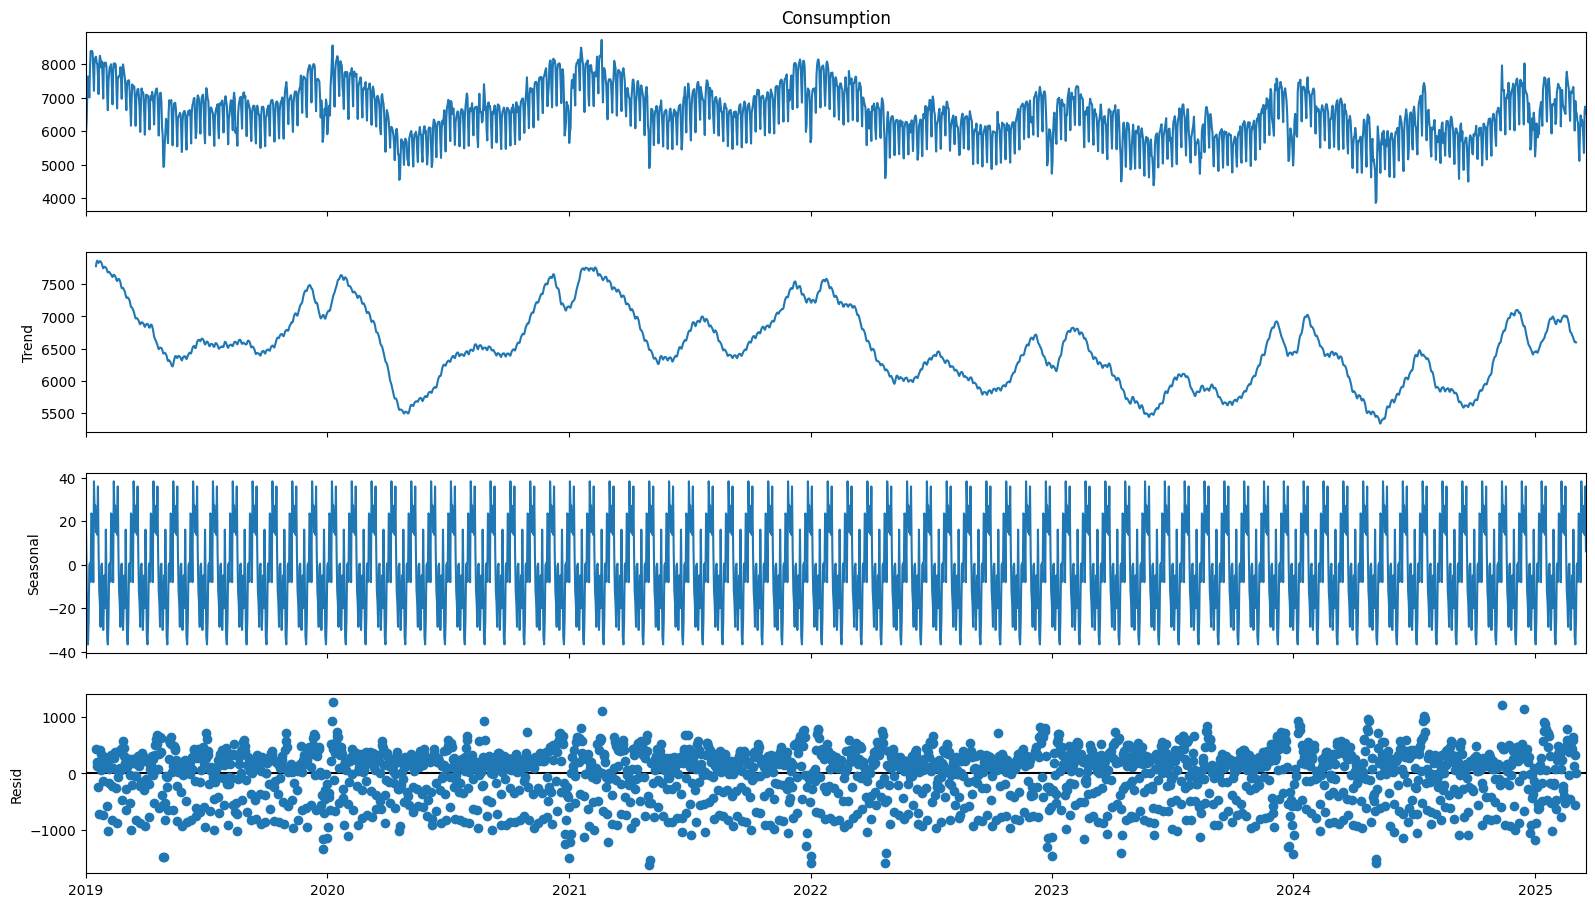

In [ ]:
decomposition = seasonal_decompose(pd_series, model = 'additive', period = 30)
fig = decomposition.plot()
fig.set_size_inches(18, 10)
plt.show()

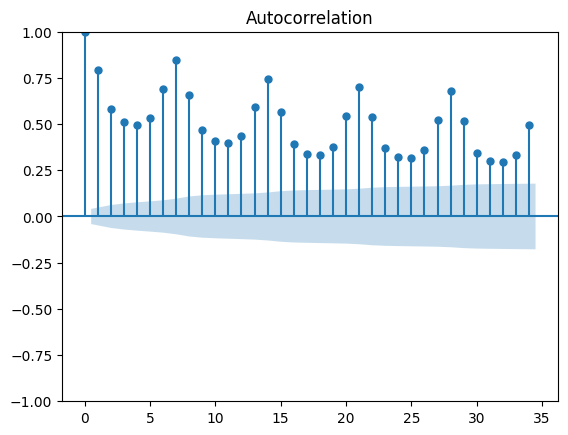

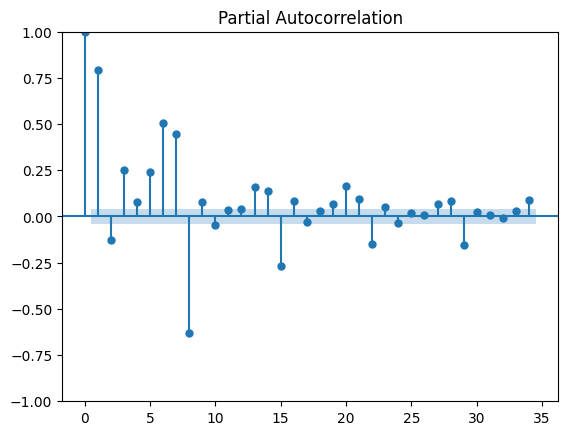

In [ ]:
plot_acf(pd_series)
plot_pacf(pd_series)
plt.show()

In [ ]:
def adf_stationarity_test(pd_series: pd.Series) -> dict:
    pd_series = pd_series.replace([np.inf, -np.inf], np.nan).dropna()
    result = adfuller(pd_series)
    p_value = result[1]
    return {"ADF Statistic": round(result[0], 4), "p-value": round(p_value, 4),
            "Stationary": p_value < 0.05}

adf_results = {name: adf_stationarity_test(s) for name, s in data.items()}
pd.DataFrame(adf_results).T.style.applymap(
    lambda v: "background-color: lightgreen" if v is True else
              "background-color: #ffcccb"    if v is False else "",
    subset=["Stationary"]
)

/tmp/ipykernel_9231/2000181155.py:9: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  pd.DataFrame(adf_results).T.style.applymap(


,ADF Statistic,p-value,Stationary
Consumption,-3.433200,0.009900,True
Production,-3.532900,0.007200,True
Nuclear,-6.749900,0.000000,True
Wind,-6.744100,0.000000,True
Hydroelectric,-3.259700,0.016800,True
Oil and Gas,-3.780000,0.003100,True
Coal,-2.897300,0.045700,True
Solar,-2.914200,0.043700,True
Biomass,-3.014800,0.033500,True


Using ARIMA model

In [ ]:
series = TimeSeries.from_series(pd_series)
val_size = 30

train = series[:-val_size]
val = series[-val_size:]


def sarima_objective(trial):

    p = trial.suggest_int("p", 0, 3)
    d = trial.suggest_int("d", 0, 2)
    q = trial.suggest_int("q", 0, 3)

    P = trial.suggest_int("P", 0, 2)
    D = trial.suggest_int("D", 0, 1)
    Q = trial.suggest_int("Q", 0, 2)

    try:
        model = ARIMA(
            p=p,
            d=d,
            q=q,
            seasonal_order=(P, D, Q, 7)
        )

        model.fit(train)
        pred = model.predict(len(val))

        return mape(val, pred)

    except:
        return float("inf")

study_sarima = optuna.create_study(direction="minimize")

study_sarima.optimize(
    sarima_objective,
    n_trials=20,
    show_progress_bar=True
)

print("\nBest params:")
print(study_sarima.best_params)

print("Best MAPE:")
print(round(study_sarima.best_value, 2))

[I 2026-05-16 18:30:01,685] A new study created in memory with name: no-name-3bb0a73b-44e6-4080-86fa-04cbd9fafa08


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-16 18:30:12,280] Trial 0 finished with value: 15.051411906147203 and parameters: {'p': 0, 'd': 2, 'q': 1, 'P': 0, 'D': 1, 'Q': 2}. Best is trial 0 with value: 15.051411906147203.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


[I 2026-05-16 18:30:28,361] Trial 1 finished with value: inf and parameters: {'p': 2, 'd': 1, 'q': 2, 'P': 2, 'D': 0, 'Q': 2}. Best is trial 0 with value: 15.051411906147203.


...

[I 2026-05-16 18:31:23,638] Trial 7 finished with value: 8.986433287746884 and parameters: {'p': 2, 'd': 1, 'q': 3, 'P': 2, 'D': 0, 'Q': 0}. Best is trial 5 with value: 6.45285684268757.
[I 2026-05-16 18:31:29,905] Trial 8 finished with value: 9.243803553039466 and parameters: {'p': 1, 'd': 0, 'q': 0, 'P': 2, 'D': 0, 'Q': 0}. Best is trial 5 with value: 6.45285684268757.
[I 2026-05-16 18:31:58,334] Trial 9 finished with value: 15.719462799349568 and parameters: {'p': 1, 'd': 2, 'q': 2, 'P': 1, 'D': 0, 'Q': 2}. Best is trial 5 with value: 6.45285684268757.
[I 2026-05-16 18:32:03,464] Trial 10 finished with value: 10.272939245755161 and parameters: {'p': 3, 'd': 0, 'q': 1, 'P': 0, 'D': 1, 'Q': 1}. Best is trial 5 with value: 6.45285684268757.


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[I 2026-05-16 18:32:11,194] Trial 11 finished with value: 10.407920901450918 and parameters: {'p': 3, 'd': 0, 'q': 3, 'P': 1, 'D': 1, 'Q': 0}. Best is trial 5 with value: 6.45285684268757.
[I 2026-05-16 18:32:18,139] Trial 12 finished with value: 6.935258615188123 and parameters: {'p': 2, 'd': 0, 'q': 3, 'P': 1, 'D': 1, 'Q': 1}. Best is trial 5 with value: 6.45285684268757.
[I 2026-05-16 18:32:26,151] Trial 13 finished with value: 7.62591264051718 and parameters: {'p': 2, 'd': 0, 'q': 2, 'P': 0, 'D': 1, 'Q': 1}. Best is trial 5 with value: 6.45285684268757.


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[I 2026-05-16 18:32:42,032] Trial 14 finished with value: 3.781331922304482 and parameters: {'p': 2, 'd': 1, 'q': 3, 'P': 2, 'D': 1, 'Q': 1}. Best is trial 14 with value: 3.781331922304482.
[I 2026-05-16 18:32:58,153] Trial 15 finished with value: 9.039387661860479 and parameters: {'p': 3, 'd': 1, 'q': 2, 'P': 2, 'D': 1, 'Q': 1}. Best is trial 14 with value: 3.781331922304482.
[I 2026-05-16 18:33:09,579] Trial 16 finished with value: 3.7096037655309035 and parameters: {'p': 2, 'd': 1, 'q': 1, 'P': 2, 'D': 1, 'Q': 1}. Best is trial 16 with value: 3.7096037655309035.
[I 2026-05-16 18:33:20,205] Trial 17 finished with value: 13.303117910973558 and parameters: {'p': 2, 'd': 2, 'q': 1, 'P': 2, 'D': 1, 'Q': 1}. Best is trial 16 with value: 3.7096037655309035.
[I 2026-05-16 18:33:30,682] Trial 18 finished with value: 3.805770151563196 and parameters: {'p': 1, 'd': 1, 'q': 1, 'P': 2, 'D': 1, 'Q': 1}. Best is trial 16 with value: 3.7096037655309035.
[I 2026-05-16 18:33:40,526] Trial 19 finished

In [ ]:
best_params = study_sarima.best_params

model = ARIMA(
    p=best_params["p"],
    d=best_params["d"],
    q=best_params["q"],
    seasonal_order=(
        best_params["P"],
        best_params["D"],
        best_params["Q"],
        7
    )
)


Forecast Horizon: 15 Days
MAPE: 11.86
MAE: 684.2
MSE: 697740.49


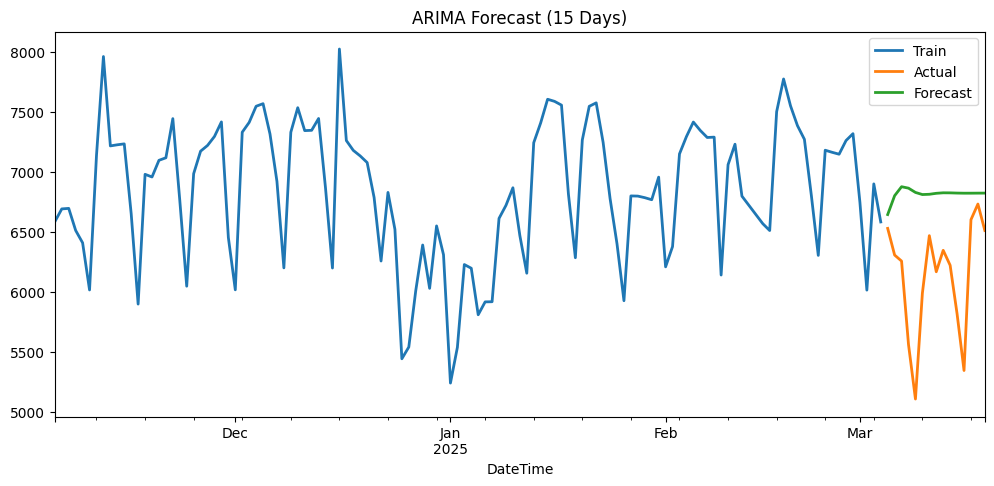


Forecast Horizon: 30 Days
MAPE: 9.76
MAE: 595.86
MSE: 542497.75


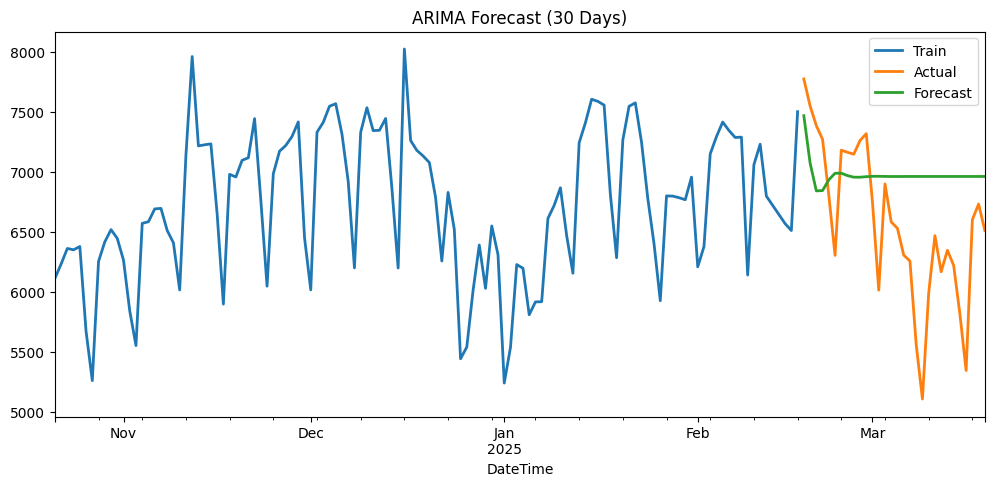


Forecast Horizon: 45 Days
MAPE: 7.54
MAE: 491.27
MSE: 360576.5


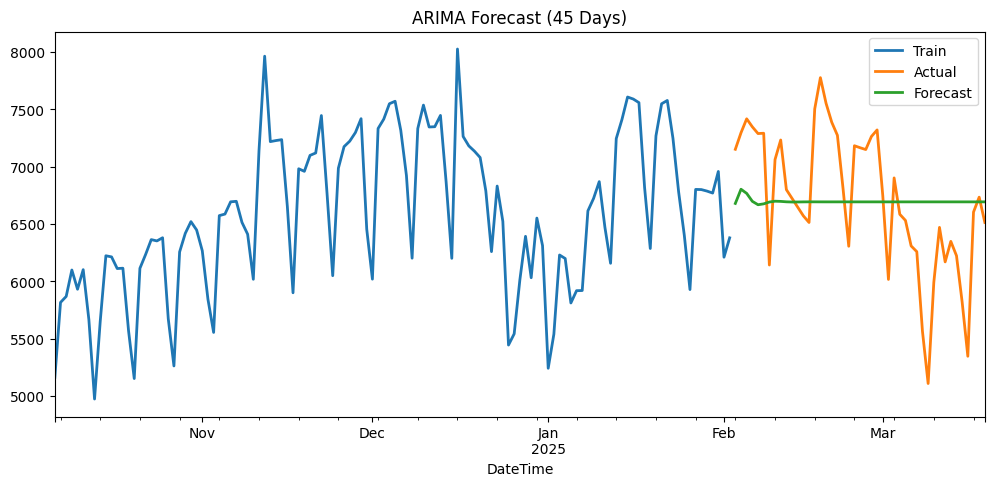

In [ ]:
forecast_horizons = [15, 30, 45]

for horizon in forecast_horizons:

    train, test = series.split_before(len(series) - horizon)

    model = ARIMA(
        p=best_params["p"],
        d=best_params["d"],
        q=best_params["q"]
    )

    model.fit(train)

    forecast = model.predict(horizon)
    print(f"\nForecast Horizon: {horizon} Days")

    print("MAPE:", round(mape(test, forecast), 2))
    print("MAE:", round(mae(test, forecast), 2))
    print("MSE:", round(mse(test, forecast), 2))

    plt.figure(figsize=(12, 5))

    train[-120:].plot(label="Train")
    test.plot(label="Actual")
    forecast.plot(label="Forecast")

    plt.title(f"ARIMA Forecast ({horizon} Days)")

    plt.legend()

    plt.show()

Using Exponential Smoothing

In [ ]:
TREND_MAP    = {"additive": ModelMode.ADDITIVE, "multiplicative": ModelMode.MULTIPLICATIVE, "none": ModelMode.NONE}
SEASONAL_MAP = {"additive": SeasonalityMode.ADDITIVE, "multiplicative": SeasonalityMode.MULTIPLICATIVE}

def es_objective(trial):

    trend_str = trial.suggest_categorical("trend", ["additive", "multiplicative", "none"])
    seasonal_str = trial.suggest_categorical("seasonal", ["additive", "multiplicative"])
    damped = trial.suggest_categorical("damped", [True, False])

    if trend_str == "none" and damped:
        return float("inf")

    try:
        model = ExponentialSmoothing(
            trend=TREND_MAP[trend_str],
            seasonal=SEASONAL_MAP[seasonal_str],
            damped=damped,
            seasonal_periods=7
        )

        train, val = series.split_before(len(series) - 30)

        model.fit(train)

        pred = model.predict(len(val))

        return mape(val, pred)

    except Exception as e:
        return float("inf")

study_es = optuna.create_study(direction="minimize")
study_es.optimize(es_objective, n_trials=15, show_progress_bar=True)
best_params = study_es.best_params
print("Best MAPE:", study_es.best_value)
print("Best params:", best_params)

[I 2026-05-16 18:33:45,152] A new study created in memory with name: no-name-09f81b87-eef9-4d43-bc40-7c8a22472b6d


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-05-16 18:33:47,133] Trial 0 finished with value: 12.975000724242 and parameters: {'trend': 'multiplicative', 'seasonal': 'additive', 'damped': False}. Best is trial 0 with value: 12.975000724242.
[I 2026-05-16 18:33:49,203] Trial 1 finished with value: 13.907777601898292 and parameters: {'trend': 'multiplicative', 'seasonal': 'additive', 'damped': True}. Best is trial 0 with value: 12.975000724242.
[I 2026-05-16 18:33:49,735] Trial 2 finished with value: 13.974855890719997 and parameters: {'trend': 'additive', 'seasonal': 'multiplicative', 'damped': True}. Best is trial 0 with value: 12.975000724242.
[I 2026-05-16 18:33:52,593] Trial 3 finished with value: 13.969601979605425 and parameters: {'trend': 'multiplicative', 'seasonal': 'multiplicative', 'damped': True}. Best is trial 0 with value: 12.975000724242.
[I 2026-05-16 18:33:52,596] Trial 4 finished with value: inf and parameters: {'trend': 'none', 'seasonal': 'multiplicative', 'damped': True}. Best is trial 0 with value: 12


Forecast Horizon: 15 Days
MAPE: 3.83
MAE: 229.72
MSE: 67248.18


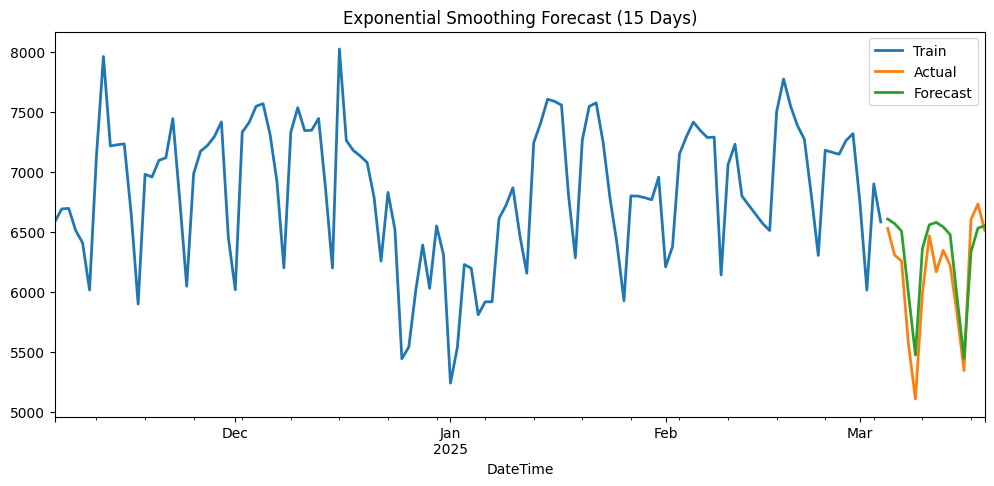


Forecast Horizon: 30 Days
MAPE: 12.98
MAE: 808.8
MSE: 869321.84


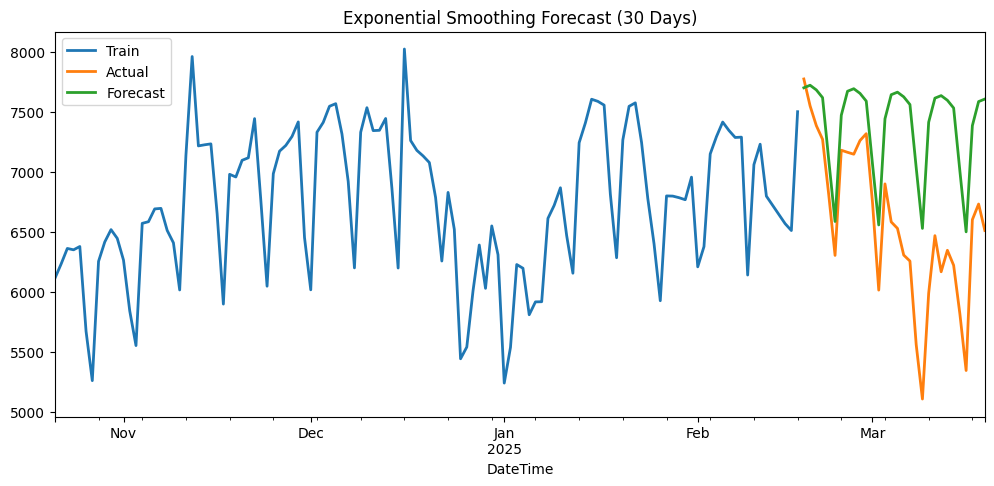


Forecast Horizon: 45 Days
MAPE: 7.34
MAE: 462.12
MSE: 367357.35


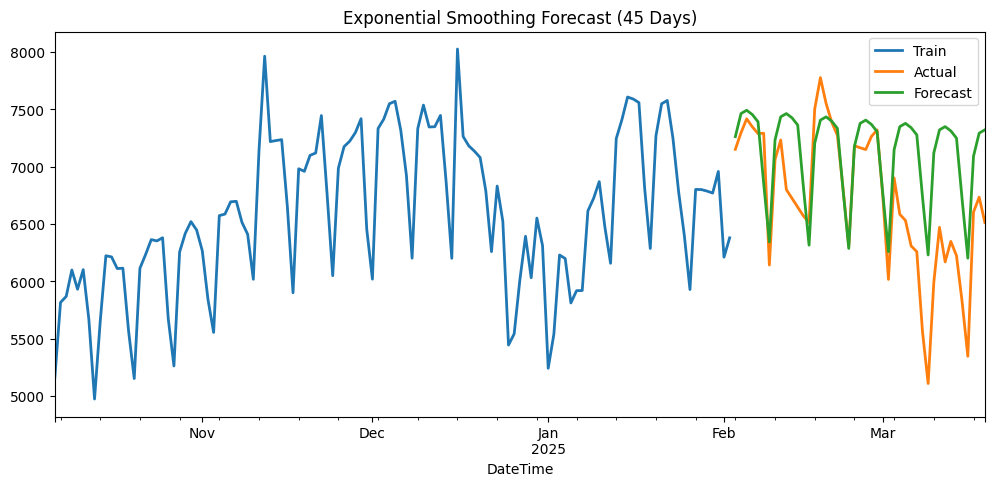

In [ ]:
forecast_horizons = [15, 30, 45]

for horizon in forecast_horizons:

    train, test = series.split_before(len(series) - horizon)

    model = ExponentialSmoothing(
        trend=TREND_MAP[best_params["trend"]],
        seasonal=SEASONAL_MAP[best_params["seasonal"]],
        damped=best_params["damped"],
        seasonal_periods=7
    )

    model.fit(train)

    forecast = model.predict(horizon)

    print(f"\nForecast Horizon: {horizon} Days")

    print("MAPE:", round(mape(test, forecast), 2))
    print("MAE:", round(mae(test, forecast), 2))
    print("MSE:", round(mse(test, forecast), 2))

    plt.figure(figsize=(12, 5))

    train[-120:].plot(label="Train")
    test.plot(label="Actual")
    forecast.plot(label="Forecast")

    plt.title(f"Exponential Smoothing Forecast ({horizon} Days)")
    plt.legend()

    plt.show()

Prophet

In [ ]:
val_size = 30

train, val = series.split_before(len(series) - val_size)

In [ ]:
def prophet_objective(trial):

    cps = trial.suggest_float("changepoint_prior_scale", 0.001, 0.5, log=True)
    sps = trial.suggest_float("seasonality_prior_scale", 0.01, 10.0, log=True)

    try:
        model = Prophet(
            changepoint_prior_scale=cps,
            seasonality_prior_scale=sps,
            seasonality_mode="additive"
        )

        model.fit(train)

        pred = model.predict(len(val))

        return mape(val, pred)

    except Exception as e:
        return float("inf")

In [ ]:
study_prophet = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_prophet.optimize(
    prophet_objective,
    n_trials=20,
    show_progress_bar=True
)

[I 2026-05-16 18:34:17,665] A new study created in memory with name: no-name-63cefc9c-c515-4d5e-9f0c-e213380b4f19


  0%|          | 0/20 [00:00<?, ?it/s]

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


[I 2026-05-16 18:34:19,499] Trial 0 finished with value: 5.5637124465761945 and parameters: {'changepoint_prior_scale': 0.010253509690168494, 'seasonality_prior_scale': 7.114476009343421}. Best is trial 0 with value: 5.5637124465761945.


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


...

[I 2026-05-16 18:34:28,441] Trial 16 finished with value: 5.580384778157153 and parameters: {'changepoint_prior_scale': 0.01769514682027426, 'seasonality_prior_scale': 0.111838678903815}. Best is trial 13 with value: 5.520511755035594.


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


[I 2026-05-16 18:34:28,751] Trial 17 finished with value: 5.665170438194824 and parameters: {'changepoint_prior_scale': 0.0020134986758601884, 'seasonality_prior_scale': 0.7484002956106014}. Best is trial 13 with value: 5.520511755035594.


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


[I 2026-05-16 18:34:29,185] Trial 18 finished with value: 5.549476523454599 and parameters: {'changepoint_prior_scale': 0.0067195718141559915, 'seasonality_prior_scale': 0.02939866261719665}. Best is trial 13 with value: 5.520511755035594.
[I 2026-05-16 18:34:29,535] Trial 19 finished with value: 5.507153861522187 and parameters: {'changepoint_prior_scale': 0.0038574186320615455, 'seasonality_prior_scale': 0.43246717378328225}. Best is trial 19 with value: 5.507153861522187.


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



PROPHET Forecast Horizon: 15 Days
MAPE: 6.14
MAE : 369.05
MSE : 172112.95


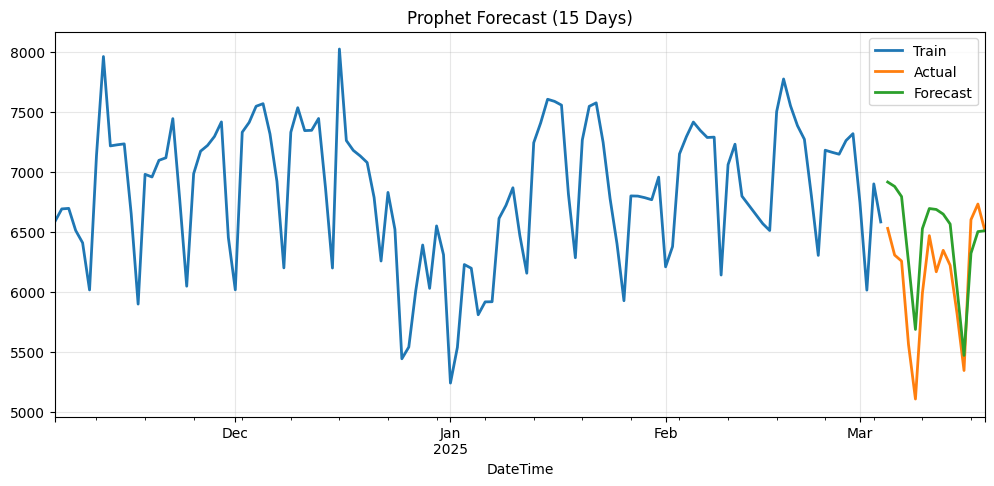

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



PROPHET Forecast Horizon: 30 Days
MAPE: 5.51
MAE : 359.26
MSE : 160305.61


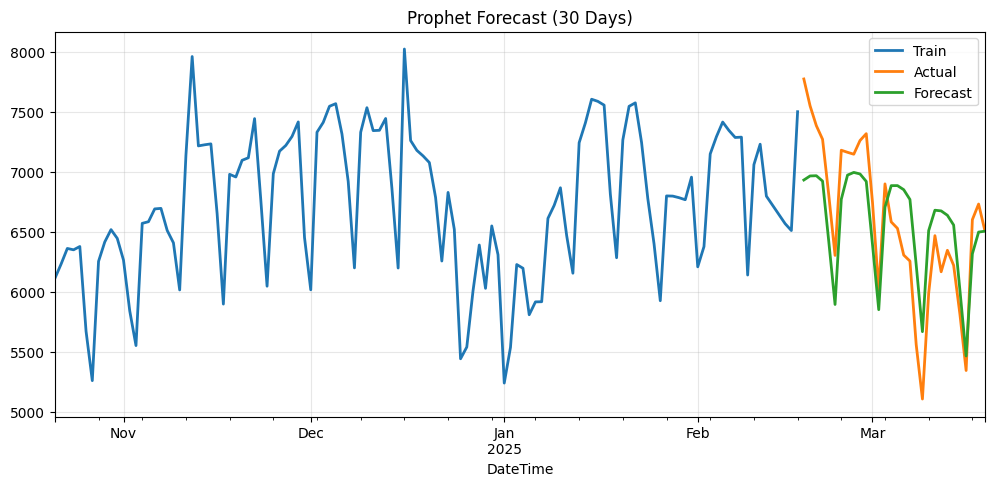

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.



PROPHET Forecast Horizon: 45 Days
MAPE: 5.72
MAE : 386.0
MSE : 191863.45


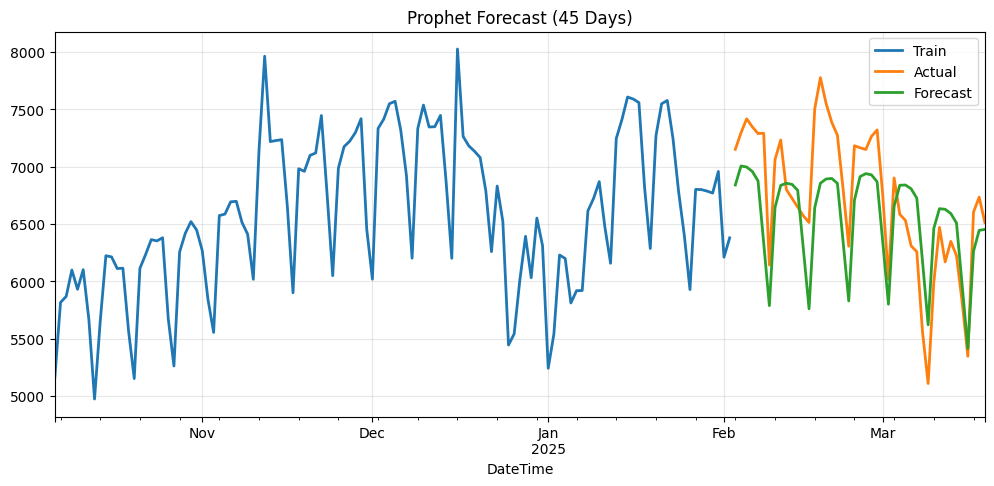

In [ ]:
best_params = study_prophet.best_params
forecast_horizons = [15, 30, 45]
for horizon in forecast_horizons:

    train, test = series.split_before(len(series) - horizon)

    model = Prophet(
        changepoint_prior_scale=best_params["changepoint_prior_scale"],
        seasonality_prior_scale=best_params["seasonality_prior_scale"],
        seasonality_mode="additive"
    )

    model.fit(train)

    forecast = model.predict(horizon)

    print(f"\nPROPHET Forecast Horizon: {horizon} Days")

    print("MAPE:", round(mape(test, forecast), 2))
    print("MAE :", round(mae(test, forecast), 2))
    print("MSE :", round(mse(test, forecast), 2))
    plt.figure(figsize=(12, 5))

    train[-120:].plot(label="Train")
    test.plot(label="Actual")
    forecast.plot(label="Forecast")

    plt.title(f"Prophet Forecast ({horizon} Days)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

XGBoost

In [ ]:
val_size = 30

train, val = series.split_before(len(series) - val_size)

def xgb_objective(trial):

    lags = trial.suggest_int("lags", 6, 24)
    n_est = trial.suggest_int("n_estimators", 50, 300)
    depth = trial.suggest_int("max_depth", 2, 8)
    lr    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    sub   = trial.suggest_float("subsample", 0.6, 1.0)

    try:
        model = XGBModel(
            lags=lags,
            n_estimators=n_est,
            max_depth=depth,
            learning_rate=lr,
            subsample=sub,
            random_state=42
        )

        model.fit(train)

        pred = model.predict(n=len(val))

        return mape(val, pred)

    except Exception as e:
        return float("inf")

study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))

study_xgb.optimize(
    xgb_objective,
    n_trials=20,
    show_progress_bar=True
)

print("\nBest MAPE:", study_xgb.best_value)
print("Best params:", study_xgb.best_params)

[I 2026-05-16 18:34:31,634] A new study created in memory with name: no-name-a1ebdb91-e450-4626-a8f9-9b42e82bc4dc


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-16 18:34:34,991] Trial 0 finished with value: 8.951574453117054 and parameters: {'lags': 13, 'n_estimators': 288, 'max_depth': 7, 'learning_rate': 0.07661100707771368, 'subsample': 0.6624074561769746}. Best is trial 0 with value: 8.951574453117054.
[I 2026-05-16 18:34:35,329] Trial 1 finished with value: 7.555266060111922 and parameters: {'lags': 8, 'n_estimators': 64, 'max_depth': 8, 'learning_rate': 0.07725378389307355, 'subsample': 0.8832290311184181}. Best is trial 1 with value: 7.555266060111922.
[I 2026-05-16 18:34:36,049] Trial 2 finished with value: 7.1931018380477045 and parameters: {'lags': 6, 'n_estimators': 293, 'max_depth': 7, 'learning_rate': 0.020589728197687916, 'subsample': 0.6727299868828402}. Best is trial 2 with value: 7.1931018380477045.
[I 2026-05-16 18:34:36,284] Trial 3 finished with value: 6.584375235881586 and parameters: {'lags': 9, 'n_estimators': 126, 'max_depth': 5, 'learning_rate': 0.04345454109729477, 'subsample': 0.7164916560792167}. Best is 


XGB Forecast Horizon: 15 Days
MAPE: 6.65
MAE : 388.21
MSE : 211705.71


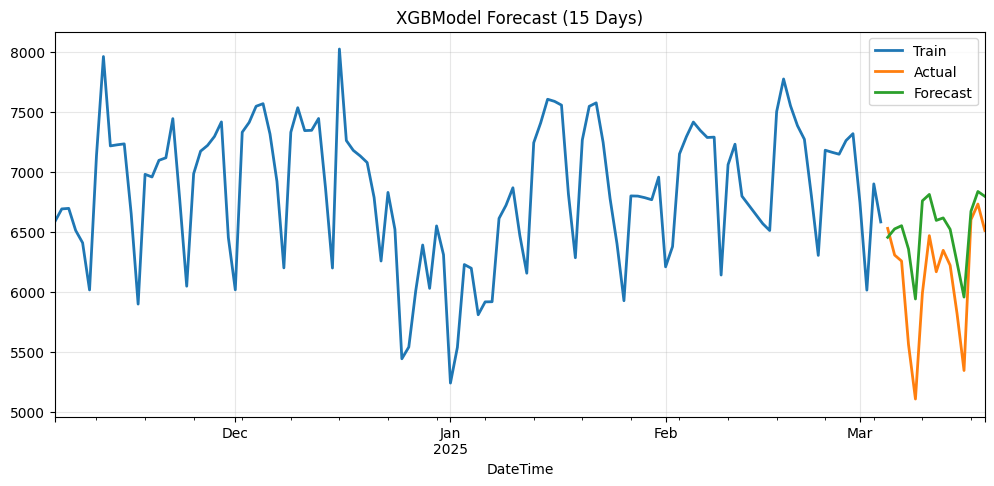


XGB Forecast Horizon: 30 Days
MAPE: 5.74
MAE : 357.6
MSE : 213753.54


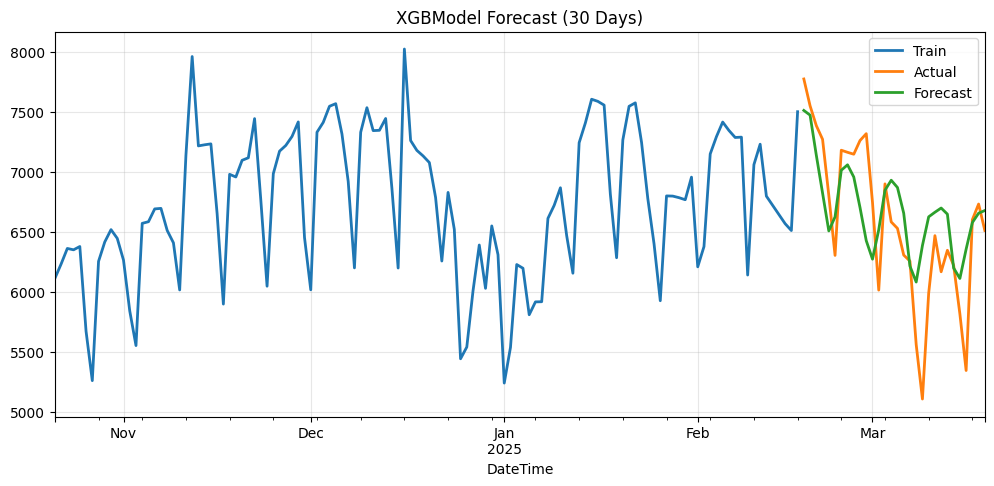


XGB Forecast Horizon: 45 Days
MAPE: 6.82
MAE : 465.83
MSE : 288005.08


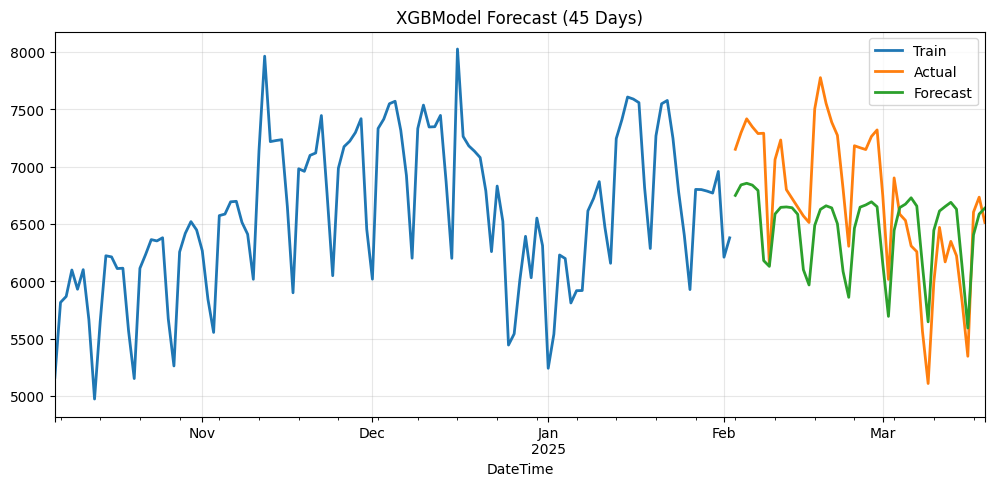

In [ ]:
forecast_horizons = [15, 30, 45]

best_params = study_xgb.best_params

for horizon in forecast_horizons:

    train, test = series.split_before(len(series) - horizon)

    model = XGBModel(
        lags=best_params["lags"],
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        learning_rate=best_params["learning_rate"],
        subsample=best_params["subsample"],
        random_state=42
    )

    model.fit(train)

    forecast = model.predict(n=horizon)

    print(f"\nXGB Forecast Horizon: {horizon} Days")

    print("MAPE:", round(mape(test, forecast), 2))
    print("MAE :", round(mae(test, forecast), 2))
    print("MSE :", round(mse(test, forecast), 2))

    plt.figure(figsize=(12, 5))

    train[-120:].plot(label="Train")
    test.plot(label="Actual")
    forecast.plot(label="Forecast")

    plt.title(f"XGBModel Forecast ({horizon} Days)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()